# Robustness Checks: Bootstrap CIs, Subgroup Analysis, and Sensitivity

This notebook stress-tests the classifier results from `Classifier_SHAP_Analysis.ipynb` before drawing any conclusions:


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

df = pd.read_csv("binary_selection_dataset.csv")
full = pd.read_csv("events_merged_full.csv")

top_genes = df["gene_or_locus"].value_counts().head(15).index
df["gene_or_locus_bucketed"] = df["gene_or_locus"].where(df["gene_or_locus"].isin(top_genes), "Other")
df["deleterious"] = df["deleterious"].fillna("NA_SCNA")
df["exonic_function"] = df["exonic_function"].fillna("NA_SCNA")
df["Progression group"] = df["Progression group"].fillna("Unknown")

EVENT_CAT = ["event_category", "event_subtype", "gene_or_locus_bucketed", "deleterious", "exonic_function", "met_site"]
PATIENT_CAT = ["Sex", "Histology", "Sarcomatoid change (Y/N)", "Overall Stage",
               "Evolutionary subtype", "ITH/WGII group", "Progression group"]
PATIENT_NUM = ["Age", "Fuhrman Grade", "Size of primary tumour (mm)", "wGII", "ITH Index"]

RF = lambda: RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=5, class_weight="balanced", random_state=42)

C:\Users\user\anaconda3\envs\Metastasis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def build_pipeline(cat_cols, num_cols, model):
    transformers = [('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)]
    if num_cols:
        transformers.append(('num', StandardScaler(), num_cols))
    return Pipeline([('pre', ColumnTransformer(transformers)), ('model', model)])


def get_oof(data, cat_cols, num_cols, model_ctor, label_col='label'):
    X = data[cat_cols + num_cols]
    y = data[label_col].values
    groups = data['patient'].values
    oof = np.zeros(len(data))
    logo = LeaveOneGroupOut()
    for tr, te in logo.split(X, y, groups):
        pipe = build_pipeline(cat_cols, num_cols, model_ctor())
        pipe.fit(X.iloc[tr], y[tr])
        oof[te] = pipe.predict_proba(X.iloc[te])[:, 1]
    return y, oof


def bootstrap_auc_ci(data, y, oof, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    patients = data['patient'].values
    unique_patients = np.unique(patients)
    aucs = []
    for _ in range(n_boot):
        sampled = rng.choice(unique_patients, size=len(unique_patients), replace=True)
        idx = np.concatenate([np.where(patients == p)[0] for p in sampled])
        y_b, oof_b = y[idx], oof[idx]
        if len(np.unique(y_b)) < 2:
            continue
        aucs.append(roc_auc_score(y_b, oof_b))
    aucs = np.array(aucs)
    return aucs.mean(), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5), len(aucs)

## 1. Bootstrap CIs for the main (pooled) models

In [3]:
results = []

y_event, oof_event = get_oof(df, EVENT_CAT, [], RF)
m, lo, hi, nv = bootstrap_auc_ci(df, y_event, oof_event)
results.append(("Pooled - Event-only", roc_auc_score(y_event, oof_event), lo, hi))

y_full, oof_full = get_oof(df, EVENT_CAT + PATIENT_CAT, PATIENT_NUM, RF)
m, lo, hi, nv = bootstrap_auc_ci(df, y_full, oof_full)
results.append(("Pooled - Full features", roc_auc_score(y_full, oof_full), lo, hi))

for name, point, lo, hi in results:
    sig = "significant (CI excludes 0.5)" if lo > 0.5 else "NOT significant (CI crosses 0.5)"
    print(f"{name:28s} AUC={point:.3f}  95% CI=[{lo:.3f}, {hi:.3f}]  -> {sig}")

Pooled - Event-only          AUC=0.583  95% CI=[0.491, 0.666]  -> NOT significant (CI crosses 0.5)
Pooled - Full features       AUC=0.600  95% CI=[0.513, 0.681]  -> significant (CI excludes 0.5)


## 2. Driver-SCNA-only subgroup analysis

In [4]:
scna = df[df["event_category"] == "driverSCNA"].copy()
print(f"Driver-SCNA subgroup: {len(scna)} events, {scna['patient'].nunique()} patients, "
      f"positive rate={scna['label'].mean():.3f}")

SCNA_CAT = ["event_subtype", "gene_or_locus", "met_site"]

y_s1, oof_s1 = get_oof(scna, SCNA_CAT, [], RF)
m1, lo1, hi1, _ = bootstrap_auc_ci(scna, y_s1, oof_s1)
print(f"Driver-SCNA, event-only:  AUC={roc_auc_score(y_s1, oof_s1):.3f}  95% CI=[{lo1:.3f}, {hi1:.3f}]")

y_s2, oof_s2 = get_oof(scna, SCNA_CAT + PATIENT_CAT, PATIENT_NUM, RF)
m2, lo2, hi2, _ = bootstrap_auc_ci(scna, y_s2, oof_s2)
print(f"Driver-SCNA, full features: AUC={roc_auc_score(y_s2, oof_s2):.3f}  95% CI=[{lo2:.3f}, {hi2:.3f}]")

Driver-SCNA subgroup: 251 events, 31 patients, positive rate=0.498
Driver-SCNA, event-only:  AUC=0.682  95% CI=[0.578, 0.772]
Driver-SCNA, full features: AUC=0.733  95% CI=[0.615, 0.828]


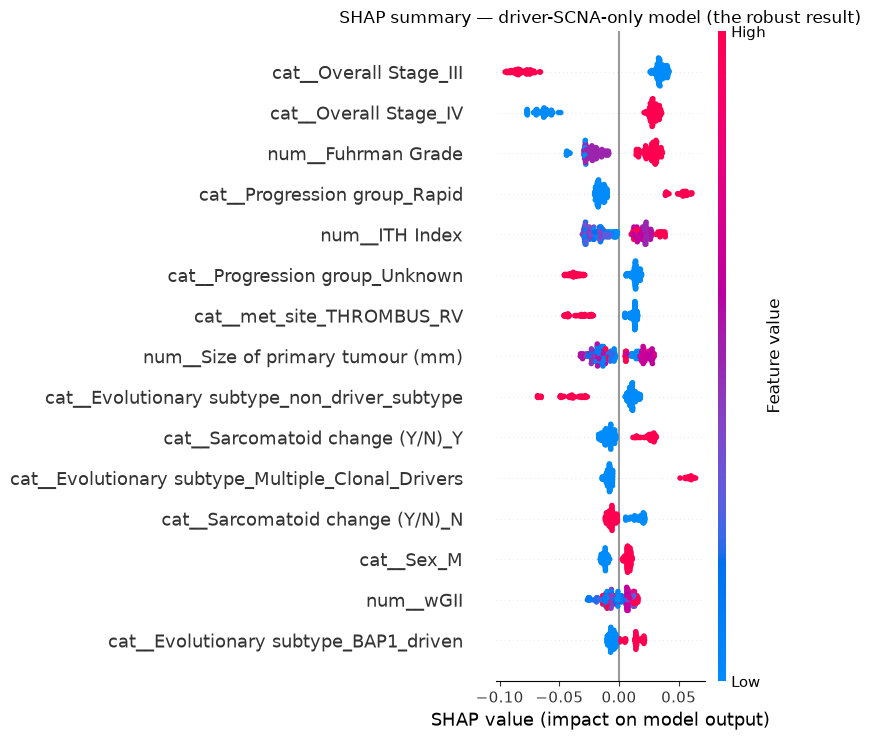

In [8]:
pre_scna = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), SCNA_CAT + PATIENT_CAT),
    ('num', StandardScaler(), PATIENT_NUM),
])
X_scna = pre_scna.fit_transform(scna[SCNA_CAT + PATIENT_CAT + PATIENT_NUM]).astype(float)
feat_names_scna = pre_scna.get_feature_names_out()

model_scna = RF()
model_scna.fit(X_scna, scna["label"].values)
explainer_scna = shap.TreeExplainer(model_scna)
sv_scna = np.array(explainer_scna.shap_values(X_scna))
sv_scna_pos = sv_scna[:, :, 1] if sv_scna.ndim == 3 else sv_scna

shap.summary_plot(sv_scna_pos, X_scna, feature_names=feat_names_scna, max_display=15, show=False)
plt.title("SHAP summary — driver-SCNA-only model (the robust result)")
plt.tight_layout()
plt.savefig(
    'SHAP_summary_driverSCNA.png',
    dpi=300,
    bbox_inches='tight'
)


plt.show()

## 3. Sensitivity check: including ambiguous "retained_subclonal" events


In [6]:
sens = full[full["selection_label"].isin(["selected", "not_selected", "retained_subclonal"])].copy()
sens["label"] = (sens["selection_label"] == "selected").astype(int)
sens["Progression group"] = sens["Progression group"].fillna("Unknown")
sens["deleterious"] = sens["deleterious"].fillna("NA_SCNA")
sens["exonic_function"] = sens["exonic_function"].fillna("NA_SCNA")
top_genes_s = sens["gene_or_locus"].value_counts().head(15).index
sens["gene_or_locus_bucketed"] = sens["gene_or_locus"].where(sens["gene_or_locus"].isin(top_genes_s), "Other")

print(f"Sensitivity dataset: {len(sens)} events (vs {len(df)} in main analysis), "
      f"positive rate={sens['label'].mean():.3f} (vs {df['label'].mean():.3f} in main analysis)")

y_sens, oof_sens = get_oof(sens, EVENT_CAT + PATIENT_CAT, PATIENT_NUM, RF)
m_s, lo_s, hi_s, _ = bootstrap_auc_ci(sens, y_sens, oof_sens)
print(f"With retained_subclonal as negative: AUC={roc_auc_score(y_sens, oof_sens):.3f}  95% CI=[{lo_s:.3f}, {hi_s:.3f}]")
print(f"(Main analysis for comparison: AUC=0.597, 95% CI=[0.506, 0.680])")

Sensitivity dataset: 1293 events (vs 1195 in main analysis), positive rate=0.340 (vs 0.368 in main analysis)
With retained_subclonal as negative: AUC=0.587  95% CI=[0.498, 0.674]
(Main analysis for comparison: AUC=0.597, 95% CI=[0.506, 0.680])
